In [2]:
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath('.')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv

load_dotenv('../.env')

MONGO_URI = os.getenv("MONGO_URI")
MONGO_DB_NAME = os.getenv("MONGO_DB_NAME", "aqi_predictor")

client = MongoClient(MONGO_URI)
db = client[MONGO_DB_NAME]

records = list(db["aqi_features"].find({}, {"_id": 0}))
df = pd.DataFrame(records)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Total records: {len(df)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Total records: 2022
Date range: 2026-02-10 13:00:00 to 2026-05-14 06:51:23

Columns: ['city', 'timestamp', 'aqi', 'aqi_category', 'aqi_change_rate', 'aqi_lag_12h', 'aqi_lag_1h', 'aqi_lag_24h', 'aqi_lag_2h', 'aqi_lag_3h', 'aqi_lag_6h', 'aqi_openweather', 'aqi_rolling_12h', 'aqi_rolling_24h', 'aqi_rolling_3h', 'aqi_rolling_6h', 'co', 'day_of_month', 'day_of_week', 'hour', 'humidity', 'is_peak_hour', 'is_weekend', 'lat', 'lon', 'month', 'nh3', 'no', 'no2', 'o3', 'pm10', 'pm2_5', 'pressure', 'so2', 'temperature', 'visibility', 'weather_desc', 'wind_deg', 'wind_speed']

Missing values:
city               0
timestamp          0
aqi                0
aqi_category       0
aqi_change_rate    0
aqi_lag_12h        0
aqi_lag_1h         0
aqi_lag_24h        0
aqi_lag_2h         0
aqi_lag_3h         0
aqi_lag_6h         0
aqi_openweather    0
aqi_rolling_12h    1
aqi_rolling_24h    1
aqi_rolling_3h     1
aqi_rolling_6h     1
co                 0
day_of_month       0
day_of_week        0
hour         

In [3]:
# Basic statistics
print("AQI Statistics:")
print(df["aqi"].describe())
print(f"\nAQI Category Distribution:")
print(df["aqi_category"].value_counts())
print(f"\nAverage AQI: {df['aqi'].mean():.2f}")
print(f"Max AQI: {df['aqi'].max()}")
print(f"Min AQI: {df['aqi'].min()}")

AQI Statistics:
count    2022.000000
mean       85.426311
std        43.896670
min         9.000000
25%        64.000000
50%        82.000000
75%        99.000000
max       500.000000
Name: aqi, dtype: float64

AQI Category Distribution:
aqi_category
moderate               1306
unhealthy_sensitive     342
good                    246
unhealthy               118
hazardous                10
Name: count, dtype: int64

Average AQI: 85.43
Max AQI: 500
Min AQI: 9


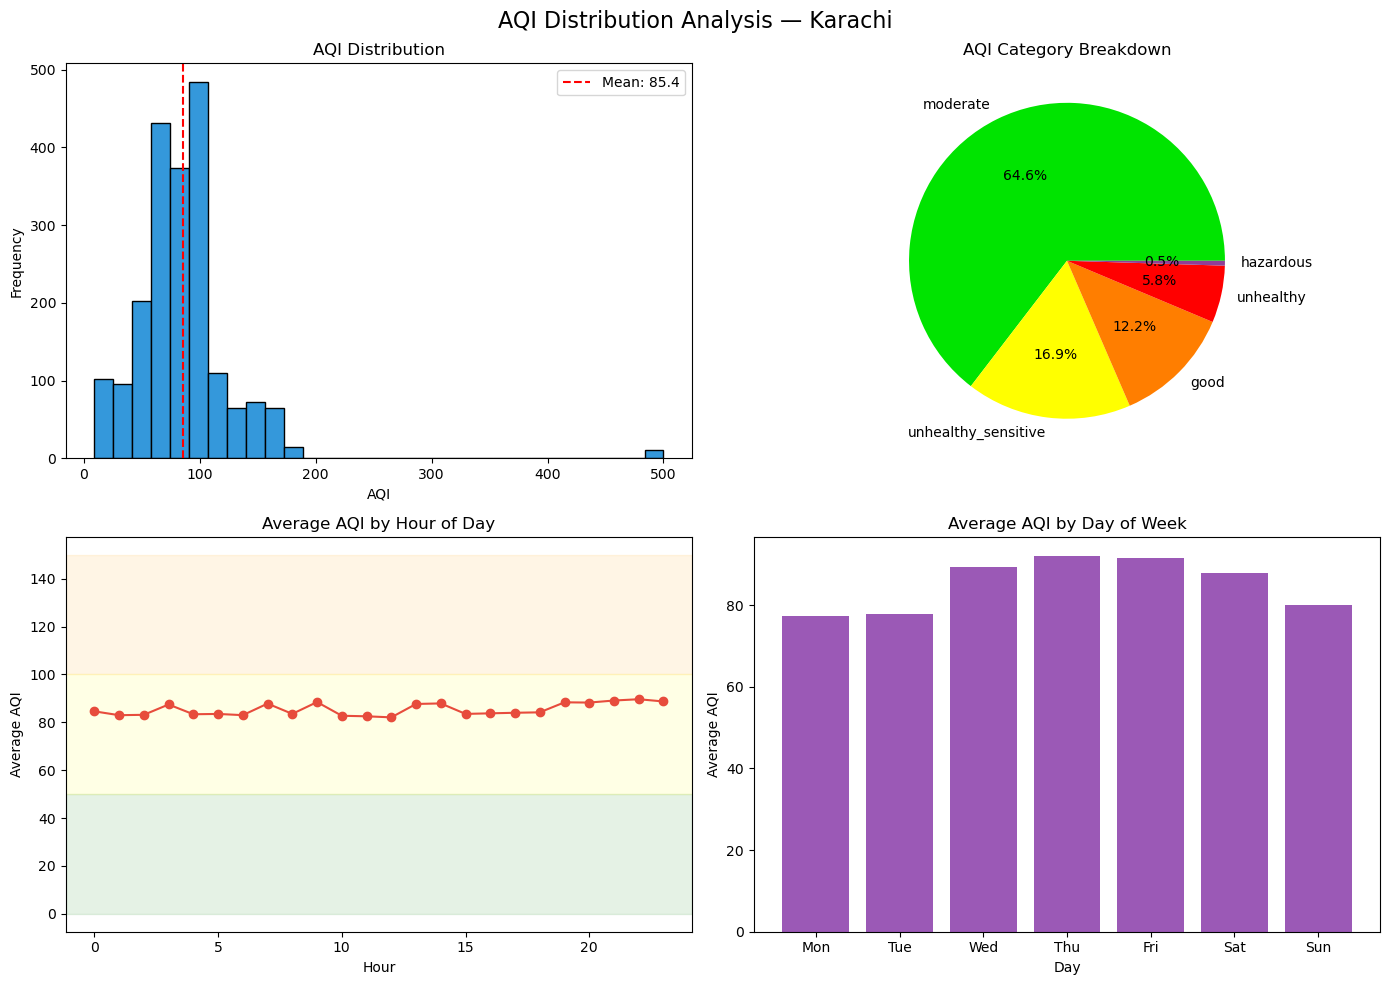

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("AQI Distribution Analysis — Karachi", fontsize=16)

# AQI distribution
axes[0, 0].hist(df["aqi"], bins=30, color="#3498db", edgecolor="black")
axes[0, 0].set_title("AQI Distribution")
axes[0, 0].set_xlabel("AQI")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(df["aqi"].mean(), color="red", linestyle="--", label=f"Mean: {df['aqi'].mean():.1f}")
axes[0, 0].legend()

# AQI category pie chart
category_counts = df["aqi_category"].value_counts()
colors = ["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97", "#7e0023"]
axes[0, 1].pie(category_counts.values, labels=category_counts.index,
               autopct="%1.1f%%", colors=colors[:len(category_counts)])
axes[0, 1].set_title("AQI Category Breakdown")

# AQI by hour of day
hourly_avg = df.groupby("hour")["aqi"].mean()
axes[1, 0].plot(hourly_avg.index, hourly_avg.values, marker="o", color="#e74c3c")
axes[1, 0].set_title("Average AQI by Hour of Day")
axes[1, 0].set_xlabel("Hour")
axes[1, 0].set_ylabel("Average AQI")
axes[1, 0].axhspan(0, 50, alpha=0.1, color="green")
axes[1, 0].axhspan(50, 100, alpha=0.1, color="yellow")
axes[1, 0].axhspan(100, 150, alpha=0.1, color="orange")

# AQI by day of week
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily_avg = df.groupby("day_of_week")["aqi"].mean()
axes[1, 1].bar(day_names, daily_avg.values, color="#9b59b6")
axes[1, 1].set_title("Average AQI by Day of Week")
axes[1, 1].set_xlabel("Day")
axes[1, 1].set_ylabel("Average AQI")

plt.tight_layout()
plt.savefig("../docs/eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

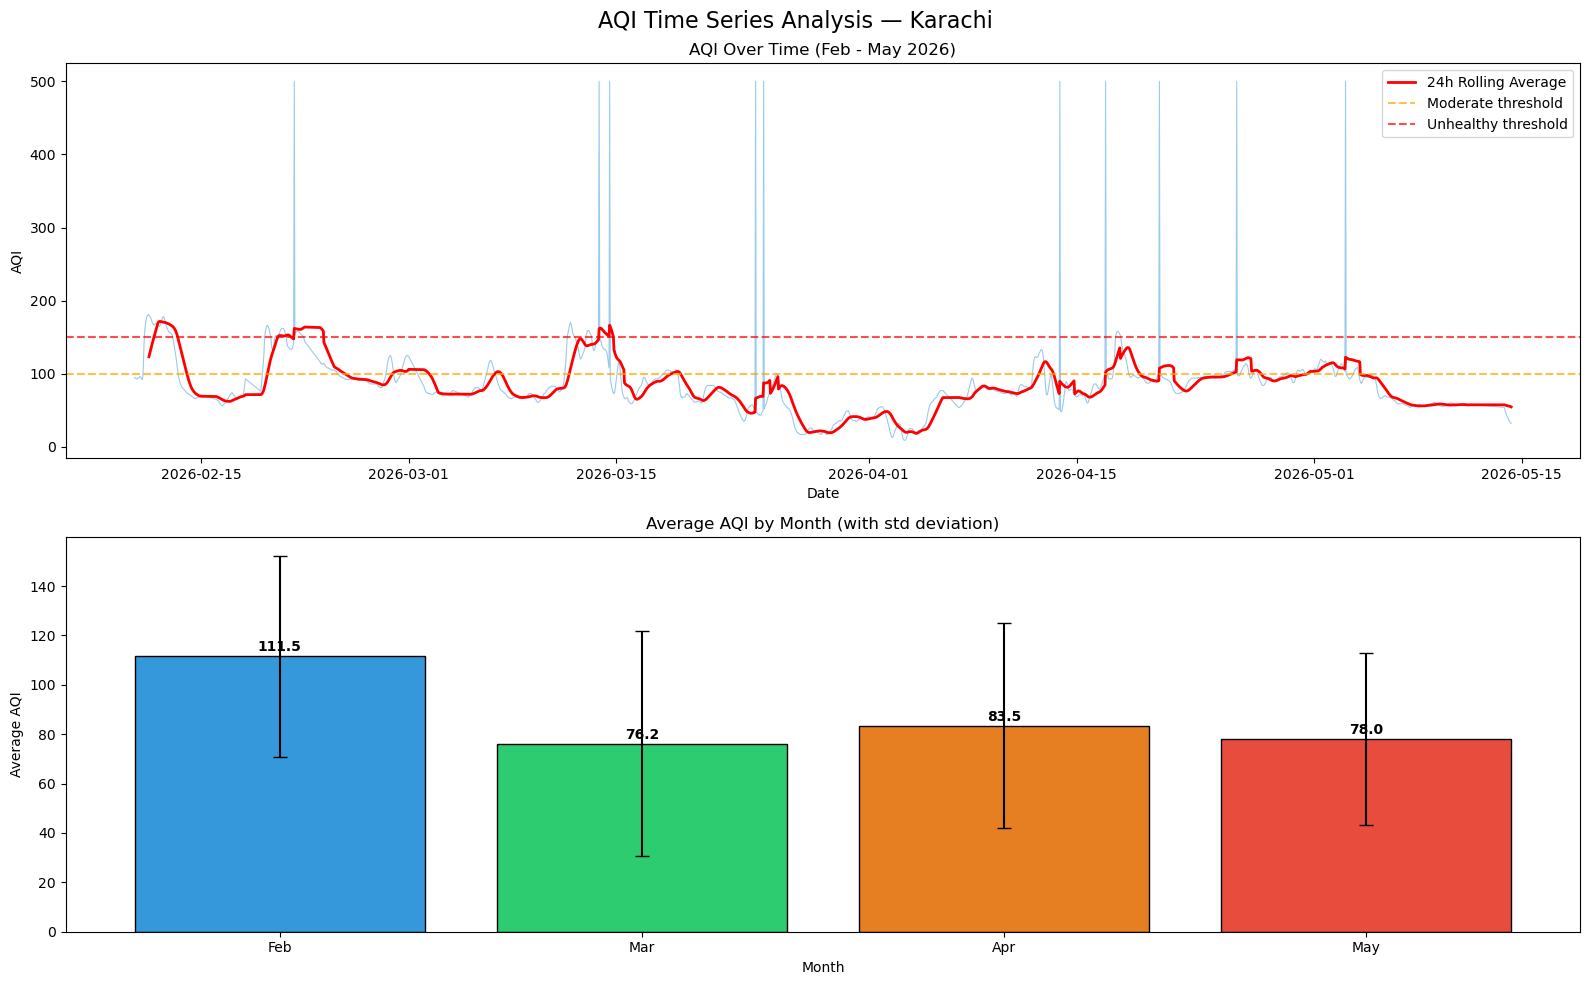

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("AQI Time Series Analysis — Karachi", fontsize=16)

df["timestamp"] = pd.to_datetime(df["timestamp"])

# Full time series
axes[0].plot(df["timestamp"], df["aqi"], alpha=0.5, color="#3498db", linewidth=0.8)
axes[0].plot(df["timestamp"], df["aqi"].rolling(24).mean(), 
             color="red", linewidth=2, label="24h Rolling Average")
axes[0].axhline(y=100, color="orange", linestyle="--", alpha=0.7, label="Moderate threshold")
axes[0].axhline(y=150, color="red", linestyle="--", alpha=0.7, label="Unhealthy threshold")
axes[0].set_title("AQI Over Time (Feb - May 2026)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("AQI")
axes[0].legend()

# Monthly average
monthly_avg = df.groupby("month")["aqi"].agg(["mean", "std"]).reset_index()
month_names = {2: "Feb", 3: "Mar", 4: "Apr", 5: "May"}
monthly_avg["month_name"] = monthly_avg["month"].map(month_names)
axes[1].bar(monthly_avg["month_name"], monthly_avg["mean"], 
            yerr=monthly_avg["std"], capsize=5,
            color=["#3498db", "#2ecc71", "#e67e22", "#e74c3c"],
            edgecolor="black")
axes[1].set_title("Average AQI by Month (with std deviation)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average AQI")

for i, row in monthly_avg.iterrows():
    axes[1].text(i, row["mean"] + 2, f"{row['mean']:.1f}", 
                ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../docs/eda_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

Outlier threshold (upper): 151.5
Number of outliers: 125

Outlier records:
               timestamp  aqi   pm2_5    pm10
16   2026-02-11 05:00:00  157   67.26  154.55
17   2026-02-11 06:00:00  166   84.25  190.70
18   2026-02-11 07:00:00  172   96.57  212.16
19   2026-02-11 08:00:00  176  104.36  220.96
20   2026-02-11 09:00:00  179  109.13  222.50
21   2026-02-11 10:00:00  180  112.01  220.26
22   2026-02-11 11:00:00  181  112.67  214.44
23   2026-02-11 12:00:00  180  111.58  207.01
24   2026-02-11 13:00:00  179  110.12  199.47
25   2026-02-11 14:00:00  178  107.21  189.48
26   2026-02-11 15:00:00  176  104.04  179.38
27   2026-02-11 16:00:00  174  100.05  168.96
28   2026-02-11 17:00:00  171   95.12  158.22
29   2026-02-11 18:00:00  169   90.31  149.47
30   2026-02-11 19:00:00  167   87.10  145.17
31   2026-02-11 20:00:00  167   87.01  145.59
32   2026-02-11 21:00:00  168   88.39  148.64
33   2026-02-11 22:00:00  168   89.30  151.51
34   2026-02-11 23:00:00  169   89.78  153.39
35   

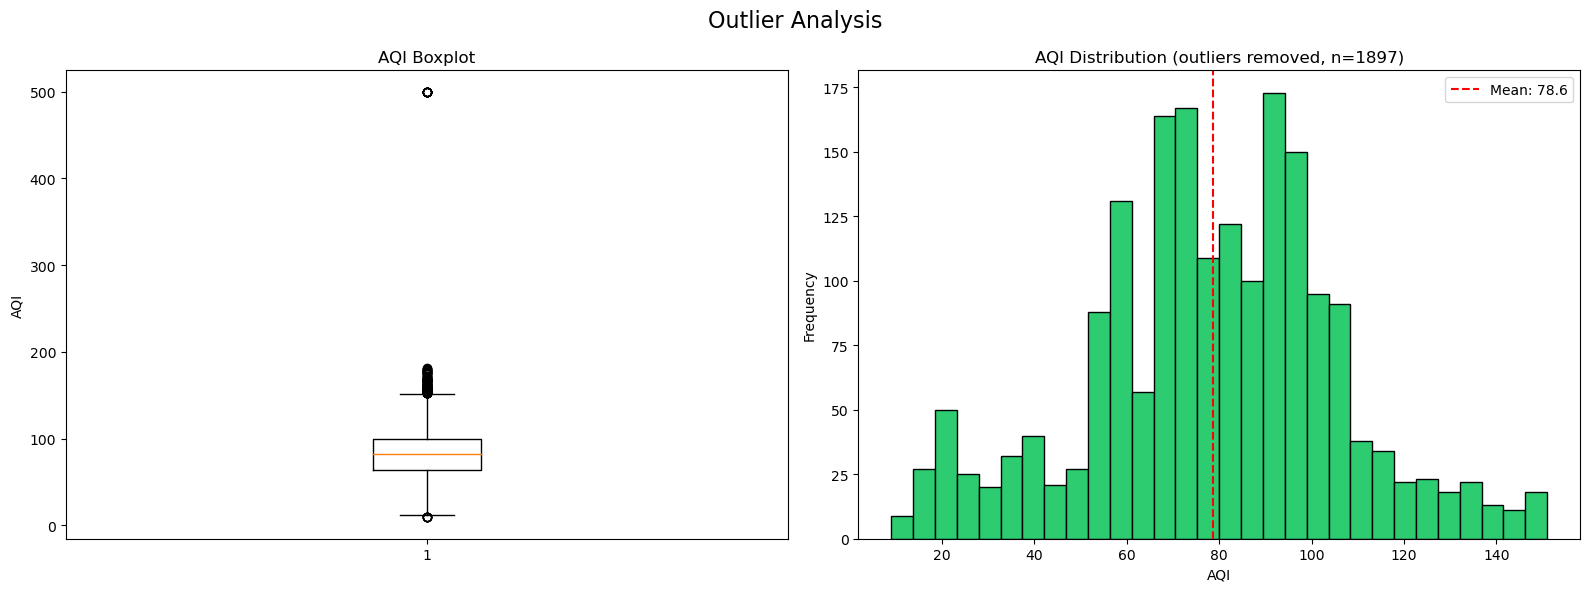

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Outlier Analysis", fontsize=16)

# Boxplot of AQI
axes[0].boxplot(df["aqi"], vert=True)
axes[0].set_title("AQI Boxplot")
axes[0].set_ylabel("AQI")

# Identify outliers
Q1 = df["aqi"].quantile(0.25)
Q3 = df["aqi"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[df["aqi"] > upper]
print(f"Outlier threshold (upper): {upper:.1f}")
print(f"Number of outliers: {len(outliers)}")
print(f"\nOutlier records:\n{outliers[['timestamp', 'aqi', 'pm2_5', 'pm10']].to_string()}")

# AQI without outliers
df_clean = df[df["aqi"] <= upper].copy()
axes[1].hist(df_clean["aqi"], bins=30, color="#2ecc71", edgecolor="black")
axes[1].set_title(f"AQI Distribution (outliers removed, n={len(df_clean)})")
axes[1].set_xlabel("AQI")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df_clean["aqi"].mean(), color="red", linestyle="--",
                label=f"Mean: {df_clean['aqi'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

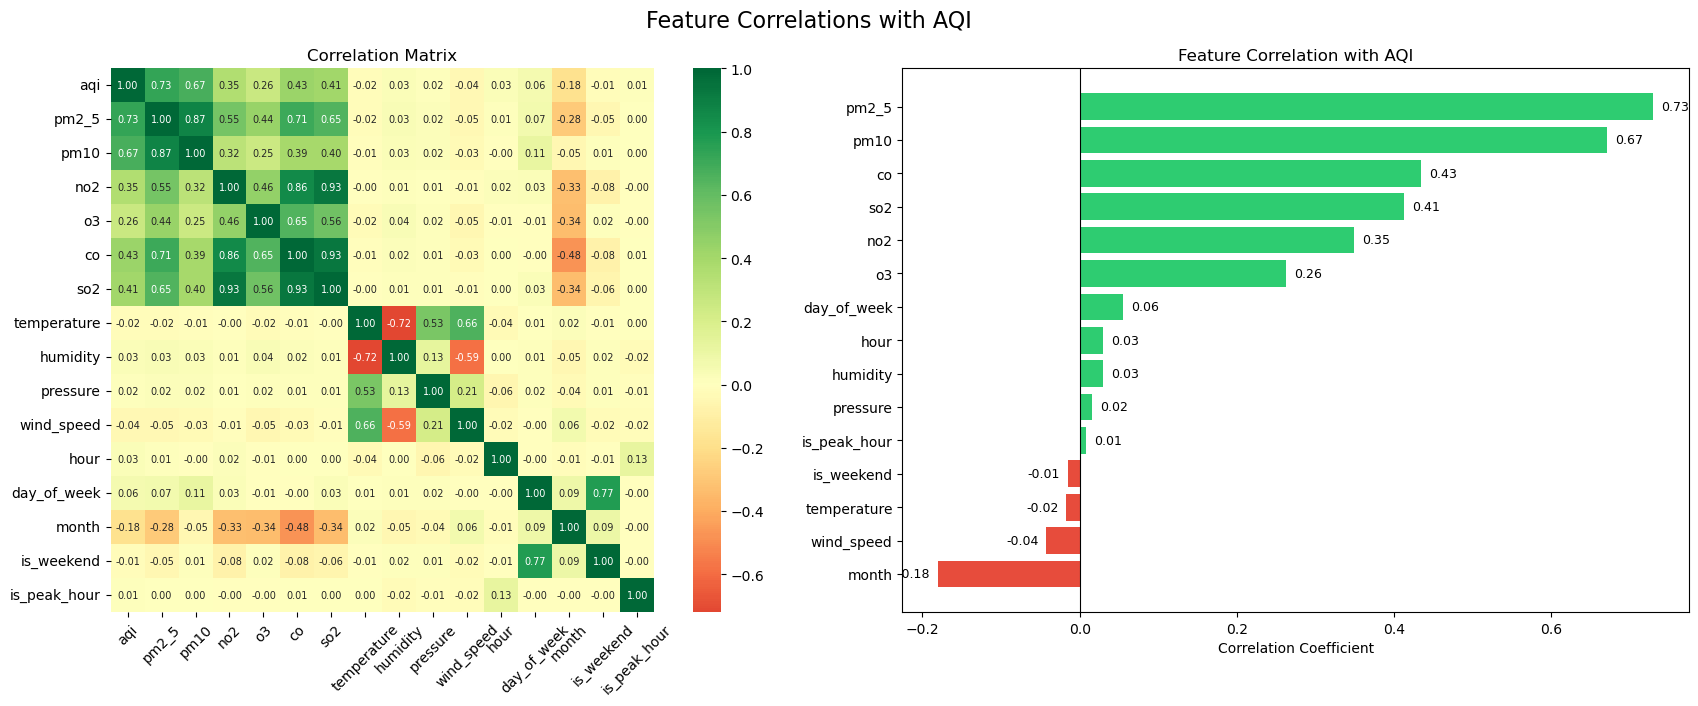


Top features correlated with AQI:
pm2_5          0.729426
pm10           0.670943
co             0.434537
so2            0.412631
no2            0.349248
o3             0.262963
month          0.180124
day_of_week    0.055168
wind_speed     0.042346
hour           0.029613
Name: aqi, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Feature Correlations with AQI", fontsize=16)

# Correlation heatmap
numeric_cols = ["aqi", "pm2_5", "pm10", "no2", "o3", "co", "so2",
                "temperature", "humidity", "pressure", "wind_speed",
                "hour", "day_of_week", "month", "is_weekend", "is_peak_hour"]

corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes[0],
    annot_kws={"size": 7},
    square=True
)
axes[0].set_title("Correlation Matrix")
axes[0].tick_params(axis="x", rotation=45)

# Top correlations with AQI specifically
aqi_corr = corr_matrix["aqi"].drop("aqi").sort_values(ascending=True)
colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in aqi_corr.values]
axes[1].barh(aqi_corr.index, aqi_corr.values, color=colors)
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with AQI")
axes[1].set_xlabel("Correlation Coefficient")

for i, (val, name) in enumerate(zip(aqi_corr.values, aqi_corr.index)):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.01, i,
                f"{val:.2f}", va="center",
                ha="left" if val >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.savefig("../docs/eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop features correlated with AQI:")
print(aqi_corr.abs().sort_values(ascending=False).head(10))

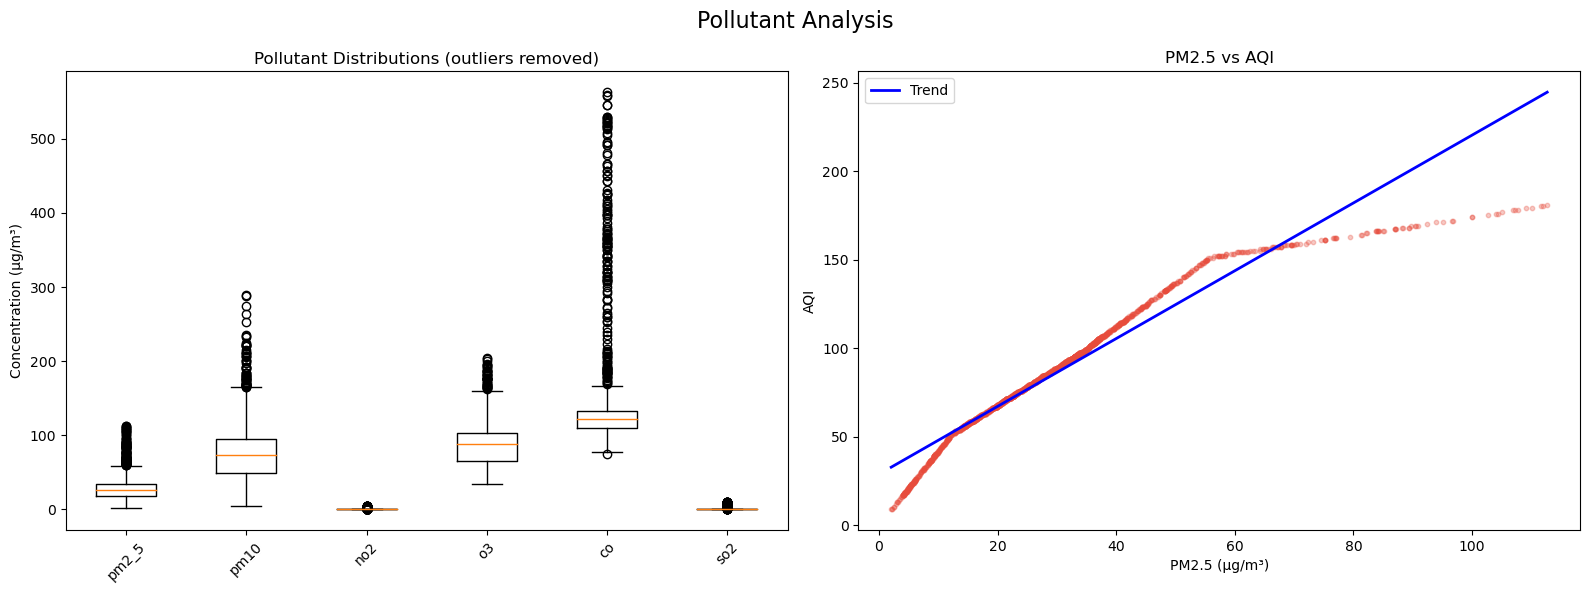


--- EDA SUMMARY & RECOMMENDATIONS ---

1. OUTLIERS: 10 records with AQI=500 are data errors (low PM2.5 contradicts high AQI)
   → Fix: Cap AQI at 400 or remove records where AQI=500 but PM2.5 < 50

2. USELESS FEATURES: hour, is_peak_hour, is_weekend have near-zero correlation with AQI
   → Fix: Remove these from feature engineering to reduce noise

3. KEY FEATURES: pm2_5, pm10, co, so2, no2 are the strongest predictors
   → These should be prioritized in the model

4. SEASONALITY: February worst (avg 111.5), March best (avg 76.2)
   → month feature is useful, keep it

5. DATA QUALITY: No missing values except 1 in rolling features (acceptable)
   → Dataset is clean enough for modeling

6. DISTRIBUTION: AQI is right-skewed, median (82) < mean (85)
   → Consider log transformation of target variable for better model fit



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Pollutant Analysis", fontsize=16)

# Pollutant distributions
pollutants = ["pm2_5", "pm10", "no2", "o3", "co", "so2"]
df_clean = df[df["aqi"] < 400].copy()

axes[0].boxplot([df_clean[p] for p in pollutants], labels=pollutants)
axes[0].set_title("Pollutant Distributions (outliers removed)")
axes[0].set_ylabel("Concentration (μg/m³)")
axes[0].tick_params(axis="x", rotation=45)

# PM2.5 vs AQI scatter
axes[1].scatter(df_clean["pm2_5"], df_clean["aqi"],
                alpha=0.3, color="#e74c3c", s=10)
axes[1].set_title("PM2.5 vs AQI")
axes[1].set_xlabel("PM2.5 (μg/m³)")
axes[1].set_ylabel("AQI")

# Add trend line
z = np.polyfit(df_clean["pm2_5"], df_clean["aqi"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean["pm2_5"].min(), df_clean["pm2_5"].max(), 100)
axes[1].plot(x_line, p(x_line), color="blue", linewidth=2, label="Trend")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/eda_pollutants.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- EDA SUMMARY & RECOMMENDATIONS ---")
print("""
1. OUTLIERS: 10 records with AQI=500 are data errors (low PM2.5 contradicts high AQI)
   → Fix: Cap AQI at 400 or remove records where AQI=500 but PM2.5 < 50

2. USELESS FEATURES: hour, is_peak_hour, is_weekend have near-zero correlation with AQI
   → Fix: Remove these from feature engineering to reduce noise

3. KEY FEATURES: pm2_5, pm10, co, so2, no2 are the strongest predictors
   → These should be prioritized in the model

4. SEASONALITY: February worst (avg 111.5), March best (avg 76.2)
   → month feature is useful, keep it

5. DATA QUALITY: No missing values except 1 in rolling features (acceptable)
   → Dataset is clean enough for modeling

6. DISTRIBUTION: AQI is right-skewed, median (82) < mean (85)
   → Consider log transformation of target variable for better model fit
""")